# SmallMinesDS — raster inspection

Sanity-check the extracted GeoTIFFs before any modelling: confirm the geometry and
band layout are what the paper claims, look at the pixel values per sensor, and put
eyes on the imagery next to its mine mask.

Each patch is `13 x 128 x 128` float32 with a `1 x 128 x 128` uint8 mask.

| Index | Bands | Sensor |
|---|---|---|
| 0–9  | blue, green, red, RE1, RE2, RE3, NIR, RE4, SWIR1, SWIR2 | Sentinel-2 L2A |
| 10–11 | VV, VH | Sentinel-1 RTC, speckle filtered |
| 12 | elevation | Copernicus DEM |

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio

def find_dir(name):
    """Locate a dataset folder whether it sits at the project root or under SmallMinesDS/."""
    for base in (Path("."), Path("SmallMinesDS")):
        if (base / name).is_dir():
            return base / name
    raise FileNotFoundError(f"could not find {name}/ — check where you extracted the zip")


DATA = find_dir("Dataset")
SPLITS = find_dir("data_splits")
YEARS = ["2016", "2022"]
print(f"images: {DATA.resolve()}\nsplits: {SPLITS.resolve()}")

S2_BANDS = ["blue", "green", "red", "rededge1", "rededge2", "rededge3",
            "nir", "rededge4", "swir1", "swir2"]
BAND_NAMES = S2_BANDS + ["vv", "vh", "dem"]
RGB = (2, 1, 0)      # red, green, blue -> band indices
NIR, SWIR1 = 6, 8

plt.rcParams["figure.dpi"] = 110

images: C:\Users\Owner\Desktop\Augustus Amedume Comp Sci Degree\Augustus Amedume Year 4 Computer Science\Semester 2\Technology Research Methods\IllegalMiningDetection\Dataset
splits: C:\Users\Owner\Desktop\Augustus Amedume Comp Sci Degree\Augustus Amedume Year 4 Computer Science\Semester 2\Technology Research Methods\IllegalMiningDetection\data_splits


## 1. Inventory

Count what actually landed on disk and confirm every image has a matching mask.

In [3]:
def tile_id(path):
    """IMG_GH_0004_2016.tif -> '0004'. Same slot in the MASK_ names."""
    return path.stem.split("_")[-2]


inventory = []
for year in YEARS:
    images = sorted((DATA / year / "IMAGE").glob("*.tif"))
    masks = sorted((DATA / year / "MASK").glob("*.tif"))
    img_ids, mask_ids = {tile_id(p) for p in images}, {tile_id(p) for p in masks}
    inventory.append({
        "year": year,
        "images": len(images),
        "masks": len(masks),
        "unpaired": len(img_ids ^ mask_ids),
    })

inventory = pd.DataFrame(inventory)
print(inventory.to_string(index=False))
print(f"\ntotal patches: {inventory['images'].sum()}")

year  images  masks  unpaired
2016    2135   2135         0
2022    2135   2135         0

total patches: 4270


## 2. Splits

`data_splits/` gives the official train/test assignment plus the share of mine pixels
in each patch.

One wrinkle: the CSVs name patches `MASK_1125_2016.tif`, but the extracted files are
`MASK_GH_1125_2016.tif`. Joining on the raw string matches nothing — key on the tile id
instead.

In [4]:
splits = []
for year in YEARS:
    df = pd.read_csv(SPLITS / f"train_test_splits_{year}.csv")
    df["year"] = year
    df["tile"] = df["patch_name"].str.extract(r"_(\d{4})_")
    splits.append(df)

splits = pd.concat(splits, ignore_index=True)

# Verify the tile-id join reaches every file on disk.
for year in YEARS:
    on_disk = {tile_id(p) for p in (DATA / year / "MASK").glob("*.tif")}
    in_csv = set(splits.loc[splits.year == year, "tile"])
    print(f"{year}: {len(in_csv & on_disk)}/{len(in_csv)} CSV rows resolve to a file")

display(splits.pivot_table(index="year", columns="split", values="tile", aggfunc="count"))

2016: 2135/2135 CSV rows resolve to a file
2022: 2135/2135 CSV rows resolve to a file


split,test,train
year,,
2016,643,1492
2022,644,1491


year
2016    54.1
2022    35.0 
^ percent of patches with no mine pixels at all


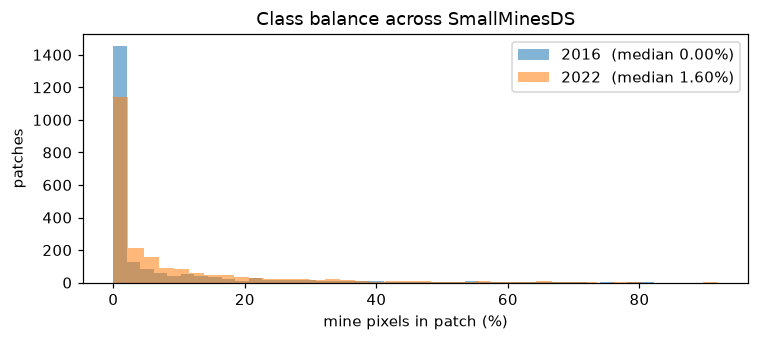

In [5]:
# Mine coverage is heavily zero-inflated -- worth knowing before picking a loss function.
fig, ax = plt.subplots(figsize=(7, 3.2))
for year in YEARS:
    s = splits.loc[splits.year == year, "class_percentage"]
    ax.hist(s, bins=40, alpha=0.55, label=f"{year}  (median {s.median():.2f}%)")
ax.set_xlabel("mine pixels in patch (%)")
ax.set_ylabel("patches")
ax.set_title("Class balance across SmallMinesDS")
ax.legend()
plt.tight_layout()

empty = splits.groupby("year")["class_percentage"].apply(lambda s: (s == 0).mean() * 100)
print(empty.round(1).to_string(), "\n^ percent of patches with no mine pixels at all")

## 3. One patch, end to end

Open a single file and read its georeferencing and per-band statistics straight from
the raster.

In [6]:
def patch_paths(year, tile):
    return (DATA / year / "IMAGE" / f"IMG_GH_{tile}_{year}.tif",
            DATA / year / "MASK" / f"MASK_GH_{tile}_{year}.tif")


def load_patch(year, tile):
    """Return (13, 128, 128) float32 image, (128, 128) uint8 mask, and the image profile."""
    img_path, mask_path = patch_paths(year, tile)
    with rasterio.open(img_path) as src:
        image, profile = src.read(), src.profile
    with rasterio.open(mask_path) as src:
        mask = src.read(1)
    return image, mask, profile


image, mask, profile = load_patch("2016", "0001")

print(f"bands       {profile['count']}")
print(f"size        {profile['height']} x {profile['width']}")
print(f"dtype       {profile['dtype']}")
print(f"crs         {profile['crs']}          # UTM zone 30N, Ghana")
print(f"resolution  {profile['transform'].a:g} m")
print(f"nodata      image {profile['nodata']}, mask 255")

bands       13
size        128 x 128
dtype       float32
crs         EPSG:32630          # UTM zone 30N, Ghana
resolution  10 m
nodata      image -9999.0, mask 255


In [7]:
stats = pd.DataFrame({
    "band": BAND_NAMES,
    "min": image.min(axis=(1, 2)),
    "mean": image.mean(axis=(1, 2)),
    "max": image.max(axis=(1, 2)),
    "std": image.std(axis=(1, 2)),
}).round(2)

# S2 sits in reflectance*10000, S1 in dB (negative), DEM in metres -- three different
# scales in one stack, so normalise per band rather than globally when you train.
display(stats)

,band,min,mean,max,std
0,blue,1006.000000,1408.699951,6660.000000,609.739990
1,green,1190.000000,1674.119995,6592.000000,570.020020
2,red,1183.000000,1615.979980,6400.000000,567.159973
3,rededge1,1415.000000,2102.709961,6702.000000,583.059998
4,rededge2,1873.000000,3386.199951,7051.000000,599.340027
5,rededge3,2013.000000,3835.560059,7226.000000,630.380005
6,nir,1903.000000,3948.340088,7704.000000,689.359985
7,rededge4,2166.000000,4184.439941,7408.000000,654.820007
8,swir1,1863.000000,3319.689941,6728.000000,575.729980
9,swir2,1420.000000,2208.479980,5227.000000,422.179993


## 4. Rendering helpers

Sentinel-2 reflectance needs a contrast stretch to be readable — raw values cluster in
a narrow range and render almost black. A per-band percentile clip is the usual fix.

In [8]:
def stretch(band, low=2, high=98):
    """Percentile-clip a single band to 0-1 for display."""
    band = np.asarray(band, dtype=np.float32)
    valid = band[np.isfinite(band) & (band != -9999)]
    if valid.size == 0:
        return np.zeros_like(band)
    lo, hi = np.percentile(valid, [low, high])
    if hi <= lo:
        return np.zeros_like(band)
    return np.clip((band - lo) / (hi - lo), 0, 1)


def composite(image, bands):
    """Stack three stretched bands into an RGB array for imshow."""
    return np.dstack([stretch(image[b]) for b in bands])


def draw_mask(ax, mask):
    """Outline the mine polygons plus a light tint, so the imagery stays readable.

    A solid fill hides the ground it is supposed to explain once coverage gets high,
    which is exactly the case worth looking at.
    """
    ax.imshow(np.ma.masked_where(mask == 0, mask),
              cmap="autumn", alpha=0.22, vmin=0, vmax=1)
    if mask.any() and not mask.all():
        ax.contour(mask, levels=[0.5], colors="#ff2d55", linewidths=1.1)

## 5. All 13 bands at once

Every layer of a single patch, with the mask alongside. Mine areas should read as bare,
bright ground in the optical bands and as a texture change in the radar.

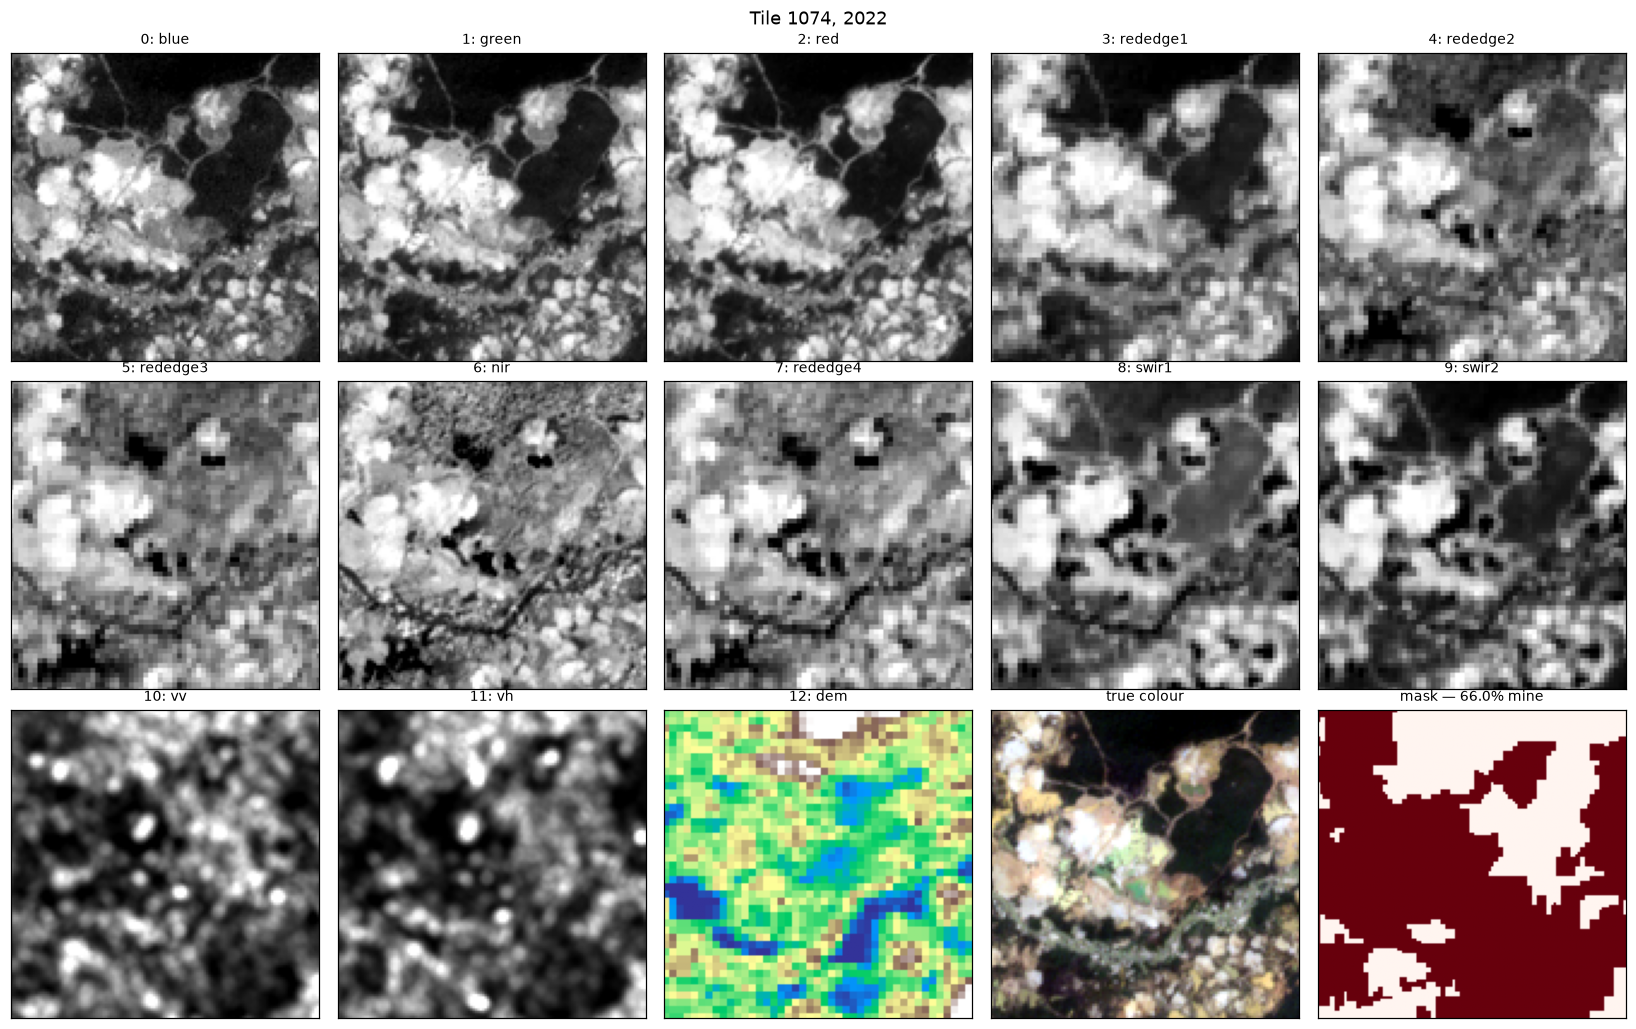

In [20]:
def plot_patch(year, tile):
    image, mask, _ = load_patch(year, tile)
    pct = 100 * mask.mean()

    fig, axes = plt.subplots(3, 5, figsize=(15, 9.5))
    for i, ax in enumerate(axes.flat[:13]):
        cmap = "terrain" if BAND_NAMES[i] == "dem" else "gray"
        ax.imshow(stretch(image[i]), cmap=cmap)
        ax.set_title(f"{i}: {BAND_NAMES[i]}", fontsize=9)

    axes.flat[13].imshow(composite(image, RGB))
    axes.flat[13].set_title("true colour", fontsize=9)

    axes.flat[14].imshow(mask, cmap="Reds", vmin=0, vmax=1)
    axes.flat[14].set_title(f"mask — {pct:.1f}% mine", fontsize=9)

    for ax in axes.flat:
        ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle(f"Tile {tile}, {year}", fontsize=12)
    plt.tight_layout()


plot_patch("2022", "1074")

## 6. Composites and mask overlay

Three views that make mining easier to spot than true colour does, plus the label drawn
on top so you can judge whether the annotation lines up with the imagery.

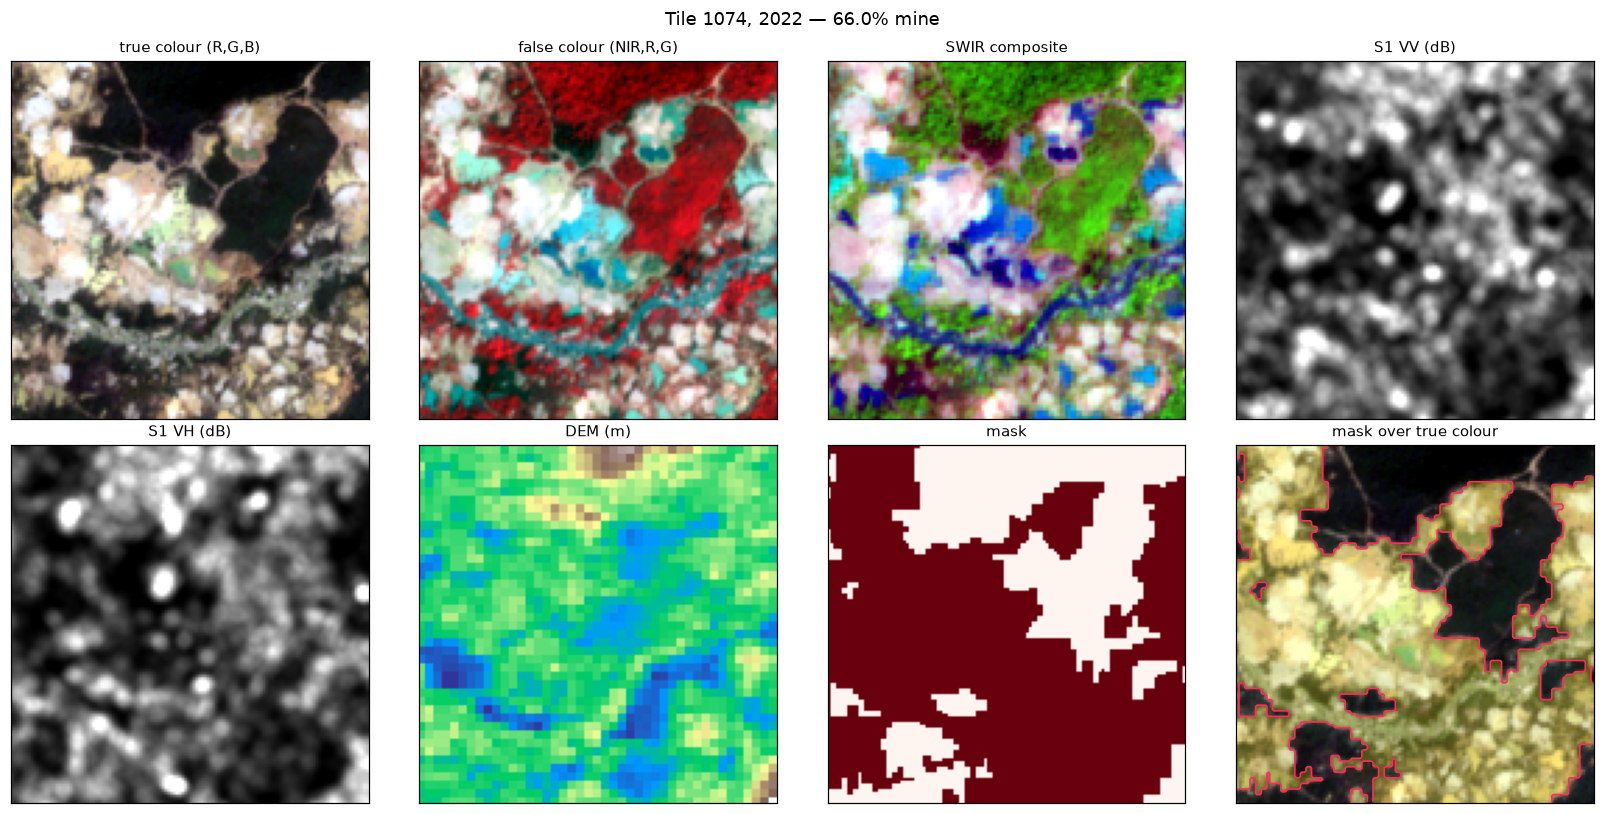

In [10]:
def plot_composites(year, tile):
    image, mask, _ = load_patch(year, tile)

    panels = [
        (composite(image, RGB), "true colour (R,G,B)", None),
        (composite(image, (NIR, 2, 1)), "false colour (NIR,R,G)", None),
        (composite(image, (SWIR1, NIR, 2)), "SWIR composite", None),
        (stretch(image[10]), "S1 VV (dB)", "gray"),
        (stretch(image[11]), "S1 VH (dB)", "gray"),
        (image[12], "DEM (m)", "terrain"),
    ]

    fig, axes = plt.subplots(2, 4, figsize=(15, 7.5))
    for ax, (data, title, cmap) in zip(axes.flat, panels):
        ax.imshow(data, cmap=cmap)
        ax.set_title(title, fontsize=10)

    axes.flat[6].imshow(mask, cmap="Reds", vmin=0, vmax=1)
    axes.flat[6].set_title("mask", fontsize=10)

    axes.flat[7].imshow(composite(image, RGB))
    draw_mask(axes.flat[7], mask)
    axes.flat[7].set_title("mask over true colour", fontsize=10)

    for ax in axes.flat:
        ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle(f"Tile {tile}, {year} — {100 * mask.mean():.1f}% mine", fontsize=12)
    plt.tight_layout()


plot_composites("2022", "1074")

## 7. 2016 vs 2022

Tile ids are consistent across years — the same ground, six years apart. This is the
change-detection signal the dataset is built for.

year,2016,2022,growth
tile,,,
1074,0.00,65.97,65.97
1126,0.28,64.11,63.83
0745,0.76,60.50,59.74
0306,2.92,57.73,54.81
0346,0.00,51.59,51.59
0970,10.38,61.92,51.54
0929,21.87,71.62,49.75
1072,0.57,43.92,43.35


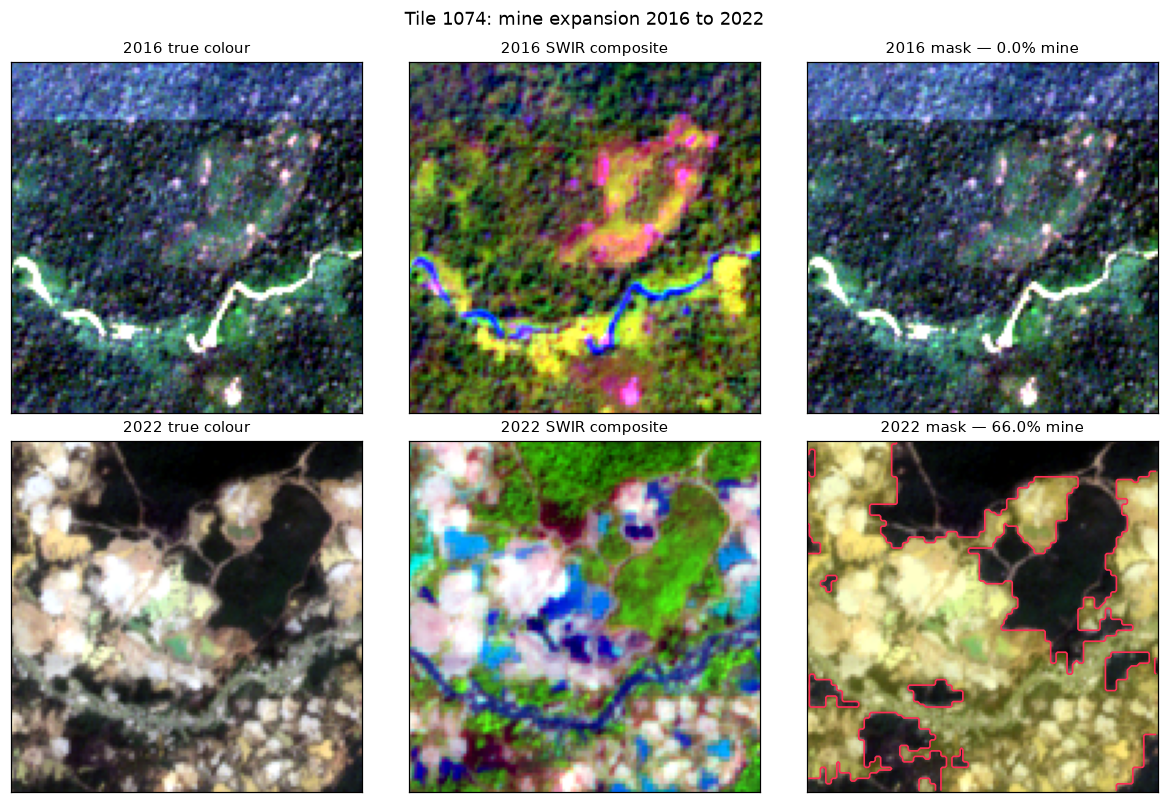

In [11]:
def plot_change(tile):
    fig, axes = plt.subplots(2, 3, figsize=(11, 7.4))
    for row, year in zip(axes, YEARS):
        image, mask, _ = load_patch(year, tile)
        rgb = composite(image, RGB)
        row[0].imshow(rgb)
        row[0].set_title(f"{year} true colour", fontsize=10)
        row[1].imshow(composite(image, (SWIR1, NIR, 2)))
        row[1].set_title(f"{year} SWIR composite", fontsize=10)
        row[2].imshow(rgb)
        draw_mask(row[2], mask)
        row[2].set_title(f"{year} mask — {100 * mask.mean():.1f}% mine", fontsize=10)

    for ax in axes.flat:
        ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle(f"Tile {tile}: mine expansion 2016 to 2022", fontsize=12)
    plt.tight_layout()


# Largest increase in mine coverage anywhere in the dataset.
change = (splits.pivot_table(index="tile", columns="year", values="class_percentage")
          .assign(growth=lambda d: d["2022"] - d["2016"])
          .nlargest(8, "growth")
          .round(2))
display(change)

plot_change(change.index[0])

## 8. A spread of patches

Sample across the coverage range to see what the labels look like at different mine
densities — from untouched forest through to a patch that is almost entirely pit.

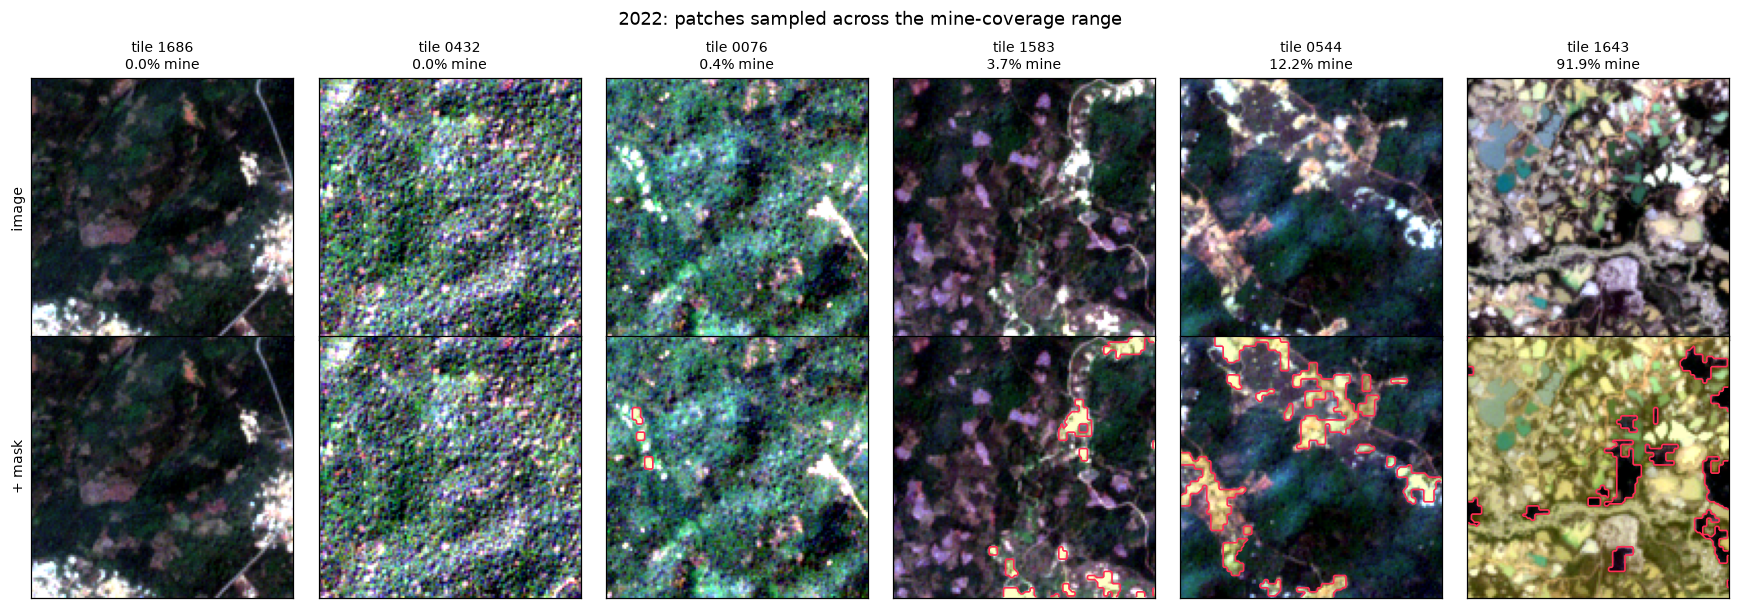

In [12]:
year = "2022"
year_splits = splits[splits.year == year].sort_values("class_percentage")
picks = year_splits.iloc[np.linspace(0, len(year_splits) - 1, 6).astype(int)]

fig, axes = plt.subplots(2, 6, figsize=(16, 5.6))
for col, (_, row) in enumerate(picks.iterrows()):
    image, mask, _ = load_patch(year, row.tile)
    axes[0, col].imshow(composite(image, RGB))
    axes[0, col].set_title(f"tile {row.tile}\n{row.class_percentage:.1f}% mine", fontsize=9)
    axes[1, col].imshow(composite(image, RGB))
    draw_mask(axes[1, col], mask)

for ax in axes.flat:
    ax.set_xticks([]); ax.set_yticks([])
axes[0, 0].set_ylabel("image", fontsize=9)
axes[1, 0].set_ylabel("+ mask", fontsize=9)
fig.suptitle(f"{year}: patches sampled across the mine-coverage range", fontsize=12)
plt.tight_layout()

## 9. Where the patches sit

Each GeoTIFF carries its UTM origin, so plotting the corners reconstructs the study
area footprint and shows how the patch grid tiles the five districts.

bounding box roughly 86 km x 74 km


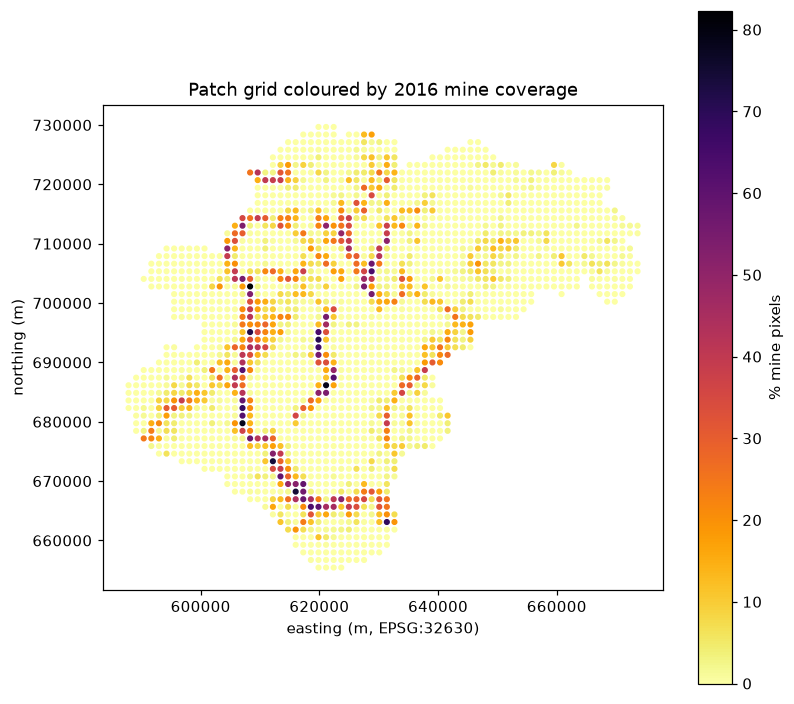

In [13]:
corners = []
for year in YEARS:
    for path in sorted((DATA / year / "IMAGE").glob("*.tif")):
        with rasterio.open(path) as src:
            corners.append({"year": year, "tile": tile_id(path),
                            "x": src.transform.c, "y": src.transform.f})

corners = pd.DataFrame(corners)
footprint = corners[corners.year == "2016"].merge(
    splits[splits.year == "2016"][["tile", "class_percentage"]], on="tile")

fig, ax = plt.subplots(figsize=(7.5, 6.5))
sc = ax.scatter(footprint.x, footprint.y, c=footprint.class_percentage,
                s=9, cmap="inferno_r")
ax.set_aspect("equal")
ax.set_xlabel("easting (m, EPSG:32630)")
ax.set_ylabel("northing (m)")
ax.set_title("Patch grid coloured by 2016 mine coverage")
fig.colorbar(sc, ax=ax, label="% mine pixels")
plt.tight_layout()

span_x = (corners.x.max() - corners.x.min()) / 1000
span_y = (corners.y.max() - corners.y.min()) / 1000
print(f"bounding box roughly {span_x:.0f} km x {span_y:.0f} km")

## Notes carried forward

- **Band scales differ by sensor.** S2 is reflectance x 10000 (~1000–7000), S1 is dB
  (negative, ~-17 to -1), DEM is metres (~130–250). Normalise per band; a single global
  mean/std will let the DEM and S2 swamp the radar.
- **Nodata is declared but sparse** — `-9999` in the images, `255` in the masks. None of
  the sampled patches contained either, but guard for them when you compute statistics.
- **Heavy class imbalance**: most patches have no mine pixels at all. Plan for that in
  the loss (dice / focal / positive weighting) and report IoU rather than accuracy.
- **Join on the tile id, not `patch_name`** — the CSVs omit the `GH_` segment that the
  extracted filenames carry.
- Tile ids are shared across 2016 and 2022, so the same id in both years is the same
  ground and can be stacked for change detection.